# 4 · Hands-on: $g^{(2)}$ from Click Data

**Interactive session · Tuesday July 28, 10:30–11:30 · work in pairs**

Three simulated Hanbury Brown–Twiss measurements, straight from the (virtual) time tagger: `source_A`, `source_B`, `source_C`. One is a **laser**, one a **thermal source**, one a **single quantum emitter** — and the file names won't tell you which.

**Your mission: identify all three from the raw time tags, with quantitative evidence.**

### Learning objectives

1. compute $g^{(2)}(\tau)$ from raw time tags via a coincidence histogram,
2. classify unknown light sources by their photon statistics,
3. quantify how uncorrelated **background** degrades an antibunching measurement.

### The data

Each `.npz` file contains an HBT recording (50:50 beamsplitter, one detector per arm, 10 s of data, ~25 000 detected photons/s total, plus realistic dark counts and timing jitter):

| array | meaning |
|---|---|
| `t1` | detector-1 arrival times, **integer nanoseconds**, sorted |
| `t2` | detector-2 arrival times, integer nanoseconds, sorted |
| `duration_ns` | total measurement time in ns |

*(The generator script is [`data/make_timetags.py`](../data/make_timetags.py) — reading it won't spoil the answer, the assignment is shuffled by the random seed.)*

In [1]:
# Setup + data loading. Works in Codespaces (files are in the repo)
# and on Google Colab (downloads the files from GitHub on first run).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})

# Where the data lives relative to this notebook; falls back to GitHub raw.
GITHUB_REPO = "laserlab/CountingPhotons"   # <- adjust if the course repo moves
DATA_DIR = "../data" if os.path.isdir("../data") else "data"

def load_source(letter: str) -> dict:
    """Load one HBT time-tag recording, downloading it if necessary.

    Returns a dict with t1, t2 (int64 nanoseconds, sorted) and
    duration_ns (float).
    """
    fname = f"source_{letter}_timetags.npz"
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        os.makedirs(DATA_DIR, exist_ok=True)
        url = (f"https://raw.githubusercontent.com/{GITHUB_REPO}"
               f"/main/data/{fname}")
        print("downloading", url)
        urllib.request.urlretrieve(url, path)
    d = np.load(path)
    return {"t1": d["t1"].astype(np.int64),   # int64: we will subtract times!
            "t2": d["t2"].astype(np.int64),
            "duration_ns": float(d["duration_ns"])}

sources = {letter: load_source(letter) for letter in "ABC"}
for letter, d in sources.items():
    rate_kcps = (d["t1"].size + d["t2"].size) / d["duration_ns"] * 1e6
    print(f"source_{letter}: {d['t1'].size:6d} + {d['t2'].size:6d} tags, "
          f"{rate_kcps:5.1f} kcps total")

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

source_A: 127119 + 127211 tags,  25.4 kcps total
source_B: 126750 + 127132 tags,  25.4 kcps total
source_C: 127110 + 126549 tags,  25.4 kcps total


Same count rate everywhere — a power meter is useless here, as promised.

## Worked example: the coincidence histogram

$g^{(2)}(\tau)$ from time tags, in words:

1. for every click on detector 1, find all detector-2 clicks within $\pm\tau_{\max}$ (fast because the arrays are sorted → `np.searchsorted`),
2. histogram the time differences $\Delta t = t_2 - t_1$ in bins of width $\Delta\tau$,
3. **normalize** by what uncorrelated streams would give: $N_{\rm acc} = r_1 r_2 T \Delta\tau$ coincidences per bin, where $r_i$ are the count rates and $T$ the total time. Dividing by $N_{\rm acc}$ makes flat = 1, so the histogram becomes $g^{(2)}(\tau)$.

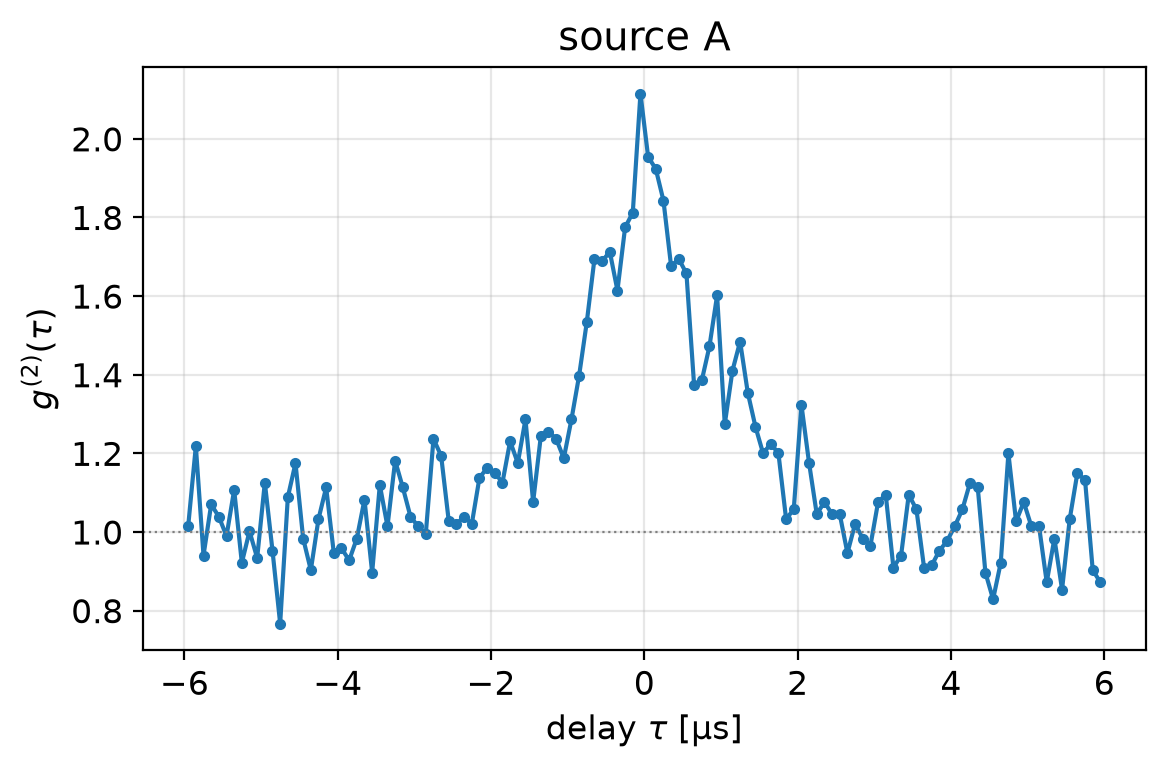

In [2]:
def g2_from_timetags(t1: np.ndarray, t2: np.ndarray, duration_ns: float,
                     window_ns: int = 6000, bin_ns: int = 100):
    """Normalized coincidence histogram g2(tau) from two HBT tag streams.

    Parameters
    ----------
    t1, t2 : sorted int64 arrays, arrival times [ns]
    duration_ns : total measurement time [ns]
    window_ns : histogram spans -window .. +window [ns]
    bin_ns : histogram bin width [ns]

    Returns
    -------
    tau_ns : bin centers [ns]
    g2 : normalized coincidence counts (dimensionless, ->1 for tau -> inf)
    """
    edges = np.arange(-window_ns, window_ns + bin_ns, bin_ns)
    counts = np.zeros(len(edges) - 1)
    # indices of the first/last t2 partner within the window, per t1 click
    lo = np.searchsorted(t2, t1 - window_ns)
    hi = np.searchsorted(t2, t1 + window_ns)
    for i, (a, b) in enumerate(zip(lo, hi)):
        if b > a:
            counts += np.histogram(t2[a:b] - t1[i], bins=edges)[0]
    # accidental (uncorrelated) coincidences per bin: r1 * r2 * T * bin
    accidentals = (t1.size / duration_ns) * (t2.size / duration_ns) \
        * duration_ns * bin_ns
    tau_ns = edges[:-1] + bin_ns / 2
    return tau_ns, counts / accidentals

# Try it on source A:
d = sources["A"]
tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
plt.plot(tau / 1000, g2, ".-")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.title("source A")
plt.tight_layout()
plt.show()

## Exercise 1 · All three sources

Compute and plot $g^{(2)}(\tau)$ for **all three sources** in one figure (shared axes, labeled). Then extract for each:

* $g^{(2)}(0)$ — average the central few bins,
* the correlation time — eyeballing is fine (at which $|\tau|$ is the feature gone?).

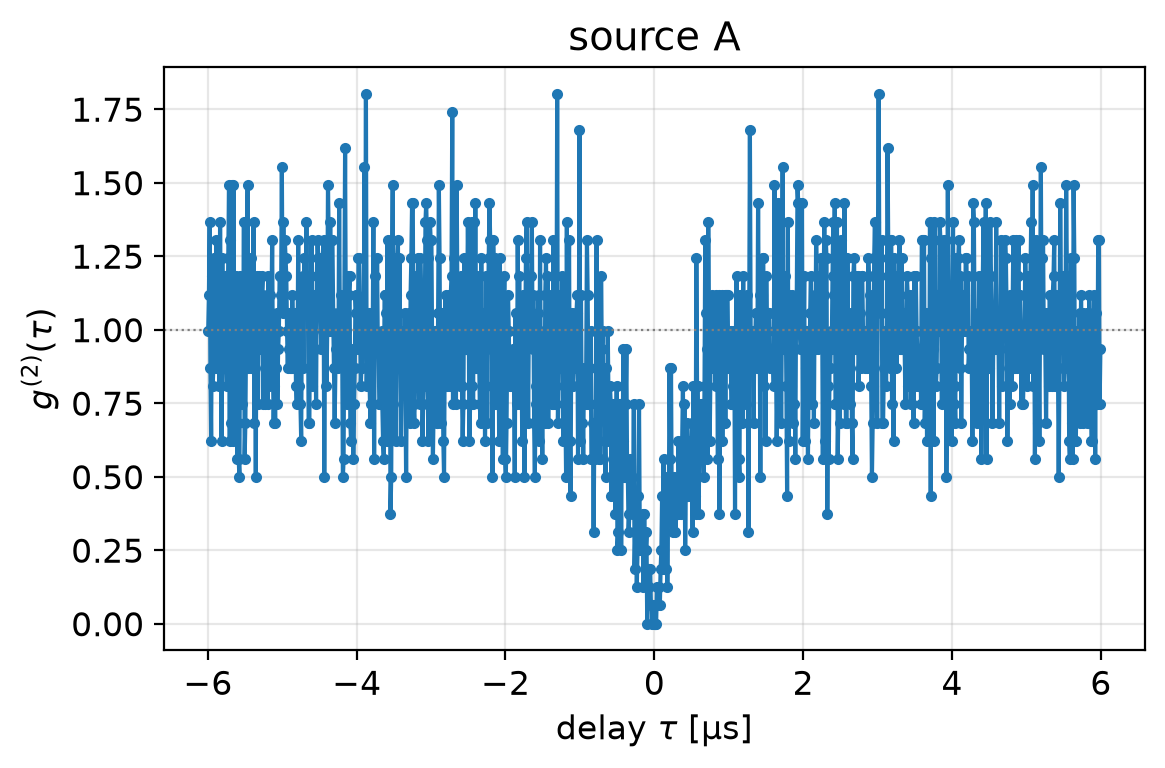

In [12]:
# YOUR CODE HERE - Exercise 1
# one figure, three g2(tau) curves + a table of g2(0) values
d = sources["C"]
tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"], bin_ns=10 )
plt.plot(tau / 1000, g2, ".-")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.title("source A")
plt.tight_layout()
plt.show()

In [5]:
d

{'t1': array([     39527,     189316,     222790, ..., 9999857114, 9999895017,
        9999906639], shape=(127110,)),
 't2': array([     12449,     116532,     129574, ..., 9999849808, 9999925258,
        9999935335], shape=(126549,)),
 'duration_ns': 10000000000.0}

## Exercise 2 · The verdict

Fill in (markdown cell — double-click):

| source | $g^{(2)}(0)$ | correlation time | identity | key evidence |
|---|---|---|---|---|
| A | | | | |
| B | | | | |
| C | | | | |

*Cross-check with theory:* the single-mode predictions are $2$, $1$, and $\approx 0$. If your emitter's $g^{(2)}(0)$ is *not* $\approx 0$ — is that physics or is that your histogram? Re-run with `bin_ns=20` on the antibunched source before you blame the source. (Remember from the lecture: dark counts also push $g^{(2)}(0)$ up. Both effects are in this data.)

*(double-click to edit — your table here)*

## Exercise 3 · How much background can antibunching survive?

Real measurements sit on uncorrelated background (dark counts, stray light). You will now *add* extra background to the antibunched source and watch the certificate $g^{(2)}(0) < 0.5$ fail.

1. Write `add_background(t, duration_ns, rate_cps, rng)` that merges Poissonian background tags into a stream (keep it sorted!).
2. For background rates from 0 to 20 000 cps *per detector*, recompute $g^{(2)}(0)$ of your antibunched source.
3. Plot $g^{(2)}(0)$ vs background fraction $p = r_{\rm bg}/(r_{\rm bg} + r_{\rm signal})$ and find where it crosses 0.5.

*Theory to compare (worth deriving at home):* with background fraction $p$ per detector, $g^{(2)}_{\rm meas}(0) \approx g^{(2)}_{\rm true}(0)(1-p)^2 + 2p(1-p) + p^2\,$.

In [4]:
# YOUR CODE HERE - Exercise 3
rng = np.random.default_rng(1)

# def add_background(t, duration_ns, rate_cps, rng): ...


## Exercise 4 · The dip is spectroscopy: fit the correlation times

From this morning's lecture: the *shape* of $g^{(2)}(\tau)$ measures the source's internal timescale — coherence time for thermal light, recovery (lifetime + re-excitation) time for a single emitter.

1. Fit the bunched source with $g^{(2)}(\tau) = 1 + a\,e^{-2|\tau|/\tau_c}$ and the antibunched source with $g^{(2)}(\tau) = 1 - b\,e^{-|\tau|/\tau_r}$ (`scipy.optimize.curve_fit`; fit the histogram *you already computed* in Exercise 1).
2. Add Poissonian error bars to your histogram points: a bin holding $N_c$ raw coincidences has uncertainty $\sqrt{N_c}$ (propagate through your normalization) — pass them to `curve_fit` via `sigma=`.
3. Report $\tau_c$ and $\tau_r$ with uncertainties. The simulation's ground truth (see [`data/make_timetags.py`](../data/make_timetags.py)): coherence time 2 µs; emitter with 1 µs excitation + 1 µs emission time. Do your fits agree — and *should* $\tau_r$ equal 2 µs? (Think: what combination of the two rates sets the antibunching recovery?)

In [5]:
# YOUR CODE HERE - Exercise 4
from scipy.optimize import curve_fit


## Stretch exercise · Measure $P(n)$ itself with click detectors

The lecture's punchline: a multiplexed click detector measures $C(k) = \sum_n P(k|n) P(n)$, a *known* linear distortion of $P(n)$ — so you can invert it. This is precisely how the fiber-loop detector of [Achilles2003] works (8 time bins, 2 APDs — the same $M = 8$ you will simulate), and the approach behind SNSPD-array photon counting today (see [Eisaman2011] for the detector landscape). Do the full pipeline, simulation to reconstruction:

1. **Simulate** a pulsed measurement: 20 000 pulses from a source with $\bar n = 2$ (do a thermal and a Fock $|2\rangle$ source), an $M = 8$ multiplexed detector with $\eta = 0.6$. Per pulse: draw $n$ from $P(n)$, keep each photon with probability $\eta$, throw the survivors into 8 bins at random, count occupied bins → $k$. Histogram the $k$'s.
2. **Build the matrix** $A_{kn} = P(k|n)$ from the lecture formula (loss binomial × bin-occupancy inclusion–exclusion; copy `click_matrix` from lecture notebook 03).
3. **Invert**: solve $C = A P$ for $P \ge 0$ with `scipy.optimize.nnls` (never plain `np.linalg.lstsq` — negative probabilities await). Normalize. Compare reconstructed vs true $P(n)$.
4. **Break it**: repeat at $\eta = 0.3$. Where does the reconstruction start inventing structure? (This ill-conditioning under loss is *the* practical limit of photon-number tomography.)

In [6]:
# YOUR CODE HERE - Stretch exercise
from scipy.optimize import nnls
n_pulses = 20_000
M, eta = 8, 0.6


## Cross-check with QuTiP (worked)

The time-tag estimate should agree with the operator expectation value $g^{(2)}(0) = \langle \hat n(\hat n-1)\rangle/\langle\hat n\rangle^2$ for the matching states:

In [7]:
def g2_zero_state(state) -> float:
    """g2(0) of a single-mode QuTiP state (ket or density matrix)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    return qutip.expect(n_op * (n_op - 1), state) / mean_n**2

N = 40
print("QuTiP single-mode predictions:")
print(f"  thermal (any nbar): g2(0) = {g2_zero_state(qutip.thermal_dm(N, 2.0)):.3f}")
print(f"  coherent (any α):   g2(0) = {g2_zero_state(qutip.coherent(N, 2.0)):.3f}")
print(f"  Fock |1>:           g2(0) = {g2_zero_state(qutip.fock(N, 1)):.3f}")

QuTiP single-mode predictions:
  thermal (any nbar): g2(0) = 2.000
  coherent (any α):   g2(0) = 1.000
  Fock |1>:           g2(0) = 0.000


## Wrap-up

Tomorrow morning we discuss the identifications together — bring your verdict table. The notebook and its sample solutions stay online; the remaining exercises are optional take-home material, **nothing needs to be handed in.**

---
---

# Sample solutions

**No peeking during the session.**

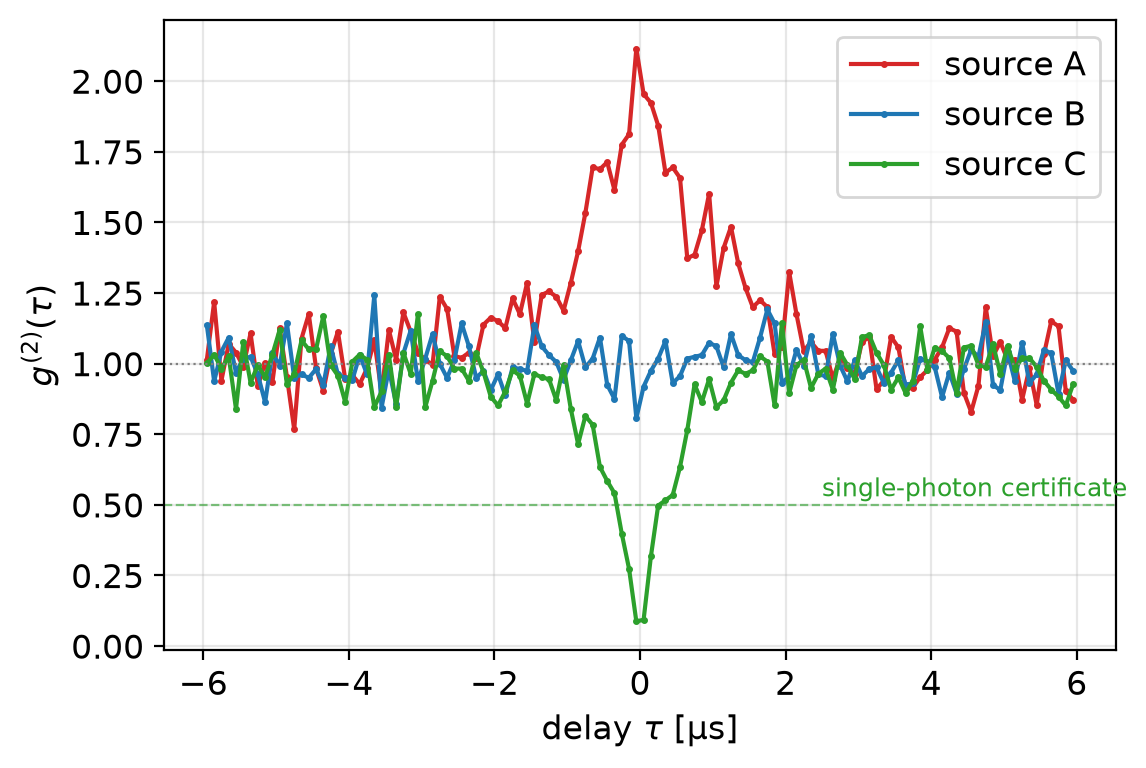

source A: g2(0) = 1.90
source B: g2(0) = 0.98
source C: g2(0) = 0.28


In [8]:
# Solution - Exercise 1
fig, ax = plt.subplots()
g2_zero_values = {}
for letter, color in zip("ABC", ["tab:red", "tab:blue", "tab:green"]):
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
    ax.plot(tau / 1000, g2, ".-", ms=3, color=color, label=f"source {letter}")
    g2_zero_values[letter] = g2[np.abs(tau) < 300].mean()
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8, alpha=0.6)
ax.annotate("single-photon certificate", (2.5, 0.53), fontsize=9,
            color="tab:green")
ax.set_xlabel(r"delay $\tau$ [µs]"); ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.legend(); plt.tight_layout(); plt.show()

for letter, v in g2_zero_values.items():
    print(f"source {letter}: g2(0) = {v:.2f}")

**Solution — Exercise 2.** With the seed shipped in the repo: **A = thermal** ($g^{(2)}(0)\approx 1.9$, bunching decays over $\sim 2$ µs), **B = coherent** ($g^{(2)}\approx 1$, flat — no structure at any $\tau$), **C = single emitter** ($g^{(2)}(0)\approx 0.3 < 0.5$: certified single-photon source; antibunching recovers over $\sim 2$ µs).

Why is C at 0.3 and not 0? Two honest experimental reasons, both built into the simulation: (i) **finite bin width** — 100 ns bins average over the first stretch of the recovery $g^{(2)}(\tau) = 1-e^{-|\tau|/\tau_r}$ with $\tau_r \approx 1$ µs (re-run with `bin_ns=20`: the center bin drops substantially); (ii) **dark counts** (200 cps/detector here) add a small uncorrelated floor. The *source* is fine — the *measurement* has resolution and background. This distinction is half of experimental quantum optics.

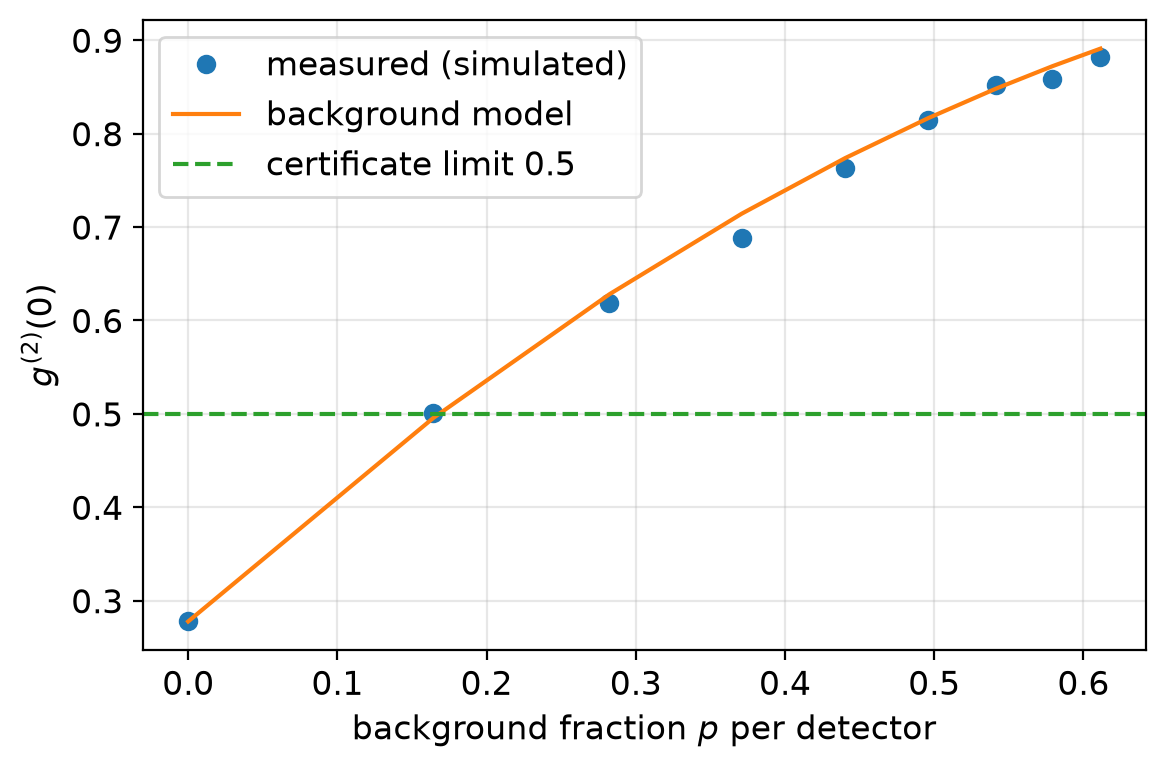

In [9]:
# Solution - Exercise 3
rng = np.random.default_rng(1)

def add_background(t: np.ndarray, duration_ns: float, rate_cps: float,
                   rng: np.random.Generator) -> np.ndarray:
    """Merge uncorrelated Poissonian background clicks into a tag stream.

    Parameters
    ----------
    t : sorted int64 arrival times [ns]
    duration_ns : measurement duration [ns]
    rate_cps : background rate to add [counts/s]
    """
    n_bg = rng.poisson(rate_cps * duration_ns * 1e-9)
    t_bg = rng.integers(0, int(duration_ns), n_bg)
    return np.sort(np.concatenate([t, t_bg]))

d = sources["C"]                       # the antibunched source
signal_rate = d["t1"].size / (d["duration_ns"] * 1e-9)   # cps per detector

bg_rates = np.linspace(0, 20e3, 9)
fractions, g2_measured = [], []
for r_bg in bg_rates:
    t1b = add_background(d["t1"], d["duration_ns"], r_bg, rng)
    t2b = add_background(d["t2"], d["duration_ns"], r_bg, rng)
    tau, g2 = g2_from_timetags(t1b, t2b, d["duration_ns"])
    p = r_bg / (r_bg + signal_rate)
    fractions.append(p)
    g2_measured.append(g2[np.abs(tau) < 300].mean())

fractions = np.array(fractions)
g2_true = g2_measured[0]
theory = g2_true * (1 - fractions)**2 + 2 * fractions * (1 - fractions) \
    + fractions**2

plt.plot(fractions, g2_measured, "o", label="measured (simulated)")
plt.plot(fractions, theory, "-", label="background model")
plt.axhline(0.5, color="tab:green", ls="--", label="certificate limit 0.5")
plt.xlabel("background fraction $p$ per detector")
plt.ylabel(r"$g^{(2)}(0)$")
plt.legend(); plt.tight_layout(); plt.show()

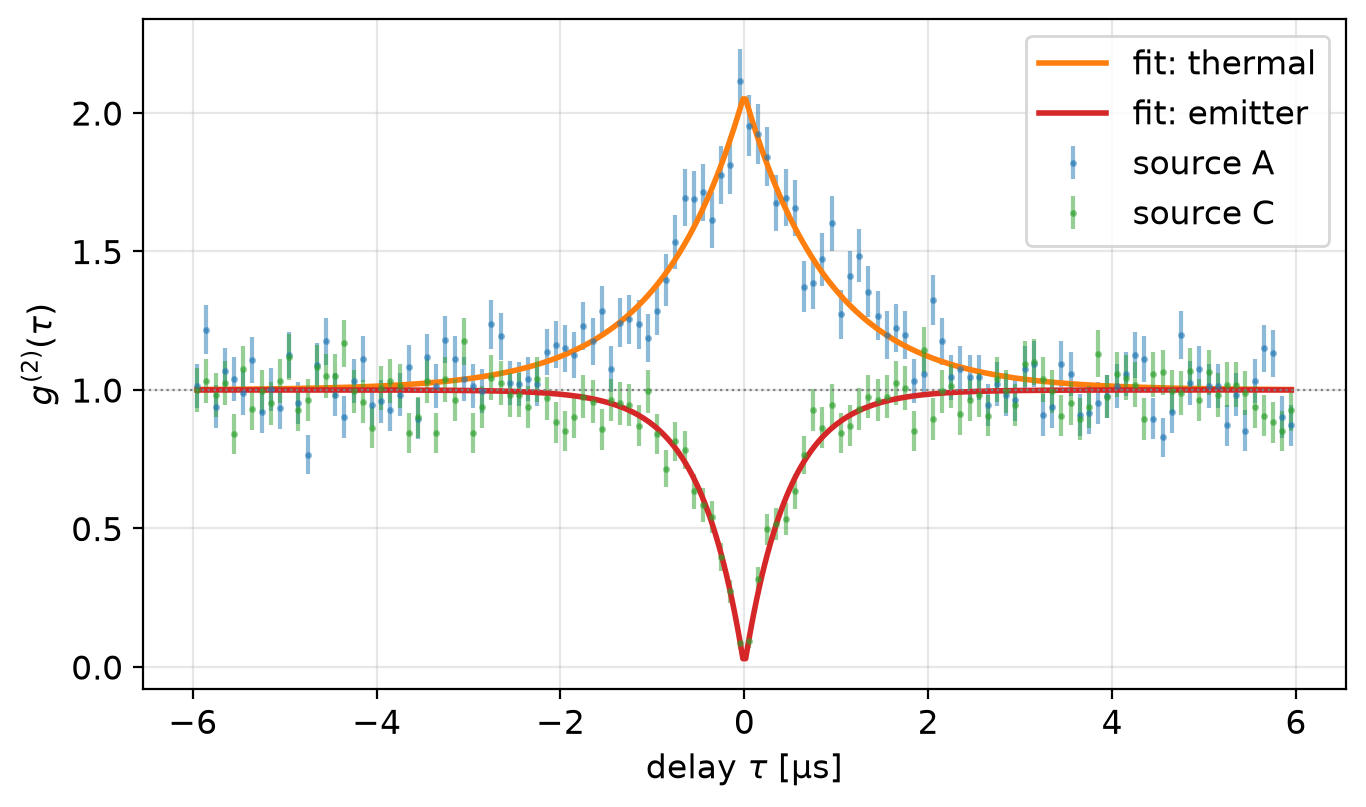

thermal:  tau_c = 1.84 ± 0.10 µs (ground truth: 2 µs)
emitter:  tau_r = 0.48 ± 0.02 µs


In [10]:
# Solution - Exercise 4
from scipy.optimize import curve_fit

def fit_g2(letter: str, model, p0, label: str):
    """Fit a g2(tau) model to one source's coincidence histogram.

    Poisson error bars: a bin with N_c raw coincidences has sigma sqrt(N_c);
    after dividing by the accidental level A the error is sqrt(N_c)/A.
    """
    d = sources[letter]
    tau, g2 = g2_from_timetags(d["t1"], d["t2"], d["duration_ns"])
    accidentals = (d["t1"].size * d["t2"].size / d["duration_ns"]) * 100  # per 100 ns bin
    sigma = np.sqrt(np.maximum(g2 * accidentals, 1)) / accidentals
    popt, pcov = curve_fit(model, tau, g2, p0=p0, sigma=sigma,
                           absolute_sigma=True)
    perr = np.sqrt(np.diag(pcov))
    plt.errorbar(tau / 1000, g2, yerr=sigma, fmt=".", ms=3, alpha=0.5,
                 label=f"source {letter}")
    tt = np.linspace(tau.min(), tau.max(), 400)
    plt.plot(tt / 1000, model(tt, *popt), "-", lw=2, label=f"fit: {label}")
    return popt, perr

def model_thermal(tau, a, tau_c):
    """Bunching of chaotic light: g2 = 1 + a*exp(-2|tau|/tau_c)."""
    return 1 + a * np.exp(-2 * np.abs(tau) / tau_c)

def model_emitter(tau, b, tau_r):
    """Antibunching recovery: g2 = 1 - b*exp(-|tau|/tau_r)."""
    return 1 - b * np.exp(-np.abs(tau) / tau_r)

plt.figure(figsize=(7, 4.2))
(a, tau_c), (da, dtau_c) = fit_g2("A", model_thermal, [1, 2000], "thermal")
(b, tau_r), (db, dtau_r) = fit_g2("C", model_emitter, [1, 500], "emitter")
plt.axhline(1, color="gray", ls=":", lw=0.8)
plt.xlabel(r"delay $\tau$ [µs]"); plt.ylabel(r"$g^{(2)}(\tau)$")
plt.legend(); plt.tight_layout(); plt.show()

print(f"thermal:  tau_c = {tau_c/1000:.2f} ± {dtau_c/1000:.2f} µs "
      "(ground truth: 2 µs)")
print(f"emitter:  tau_r = {tau_r/1000:.2f} ± {dtau_r/1000:.2f} µs")
# Why is tau_r NOT 2 µs? The photon-to-photon gap is the SUM of two
# exponentials (1 µs excitation + 1 µs emission). For equal rates this
# renewal process has *exactly* g2(tau) = 1 - exp(-2 tau / tau_0) with
# tau_0 = 1 µs, i.e. a recovery constant tau_0/2 = 0.5 µs: the recovery
# reflects the total cycle RATE, not the cycle duration. Fit shapes are
# physics - always ask which combination of rates your time constant is.

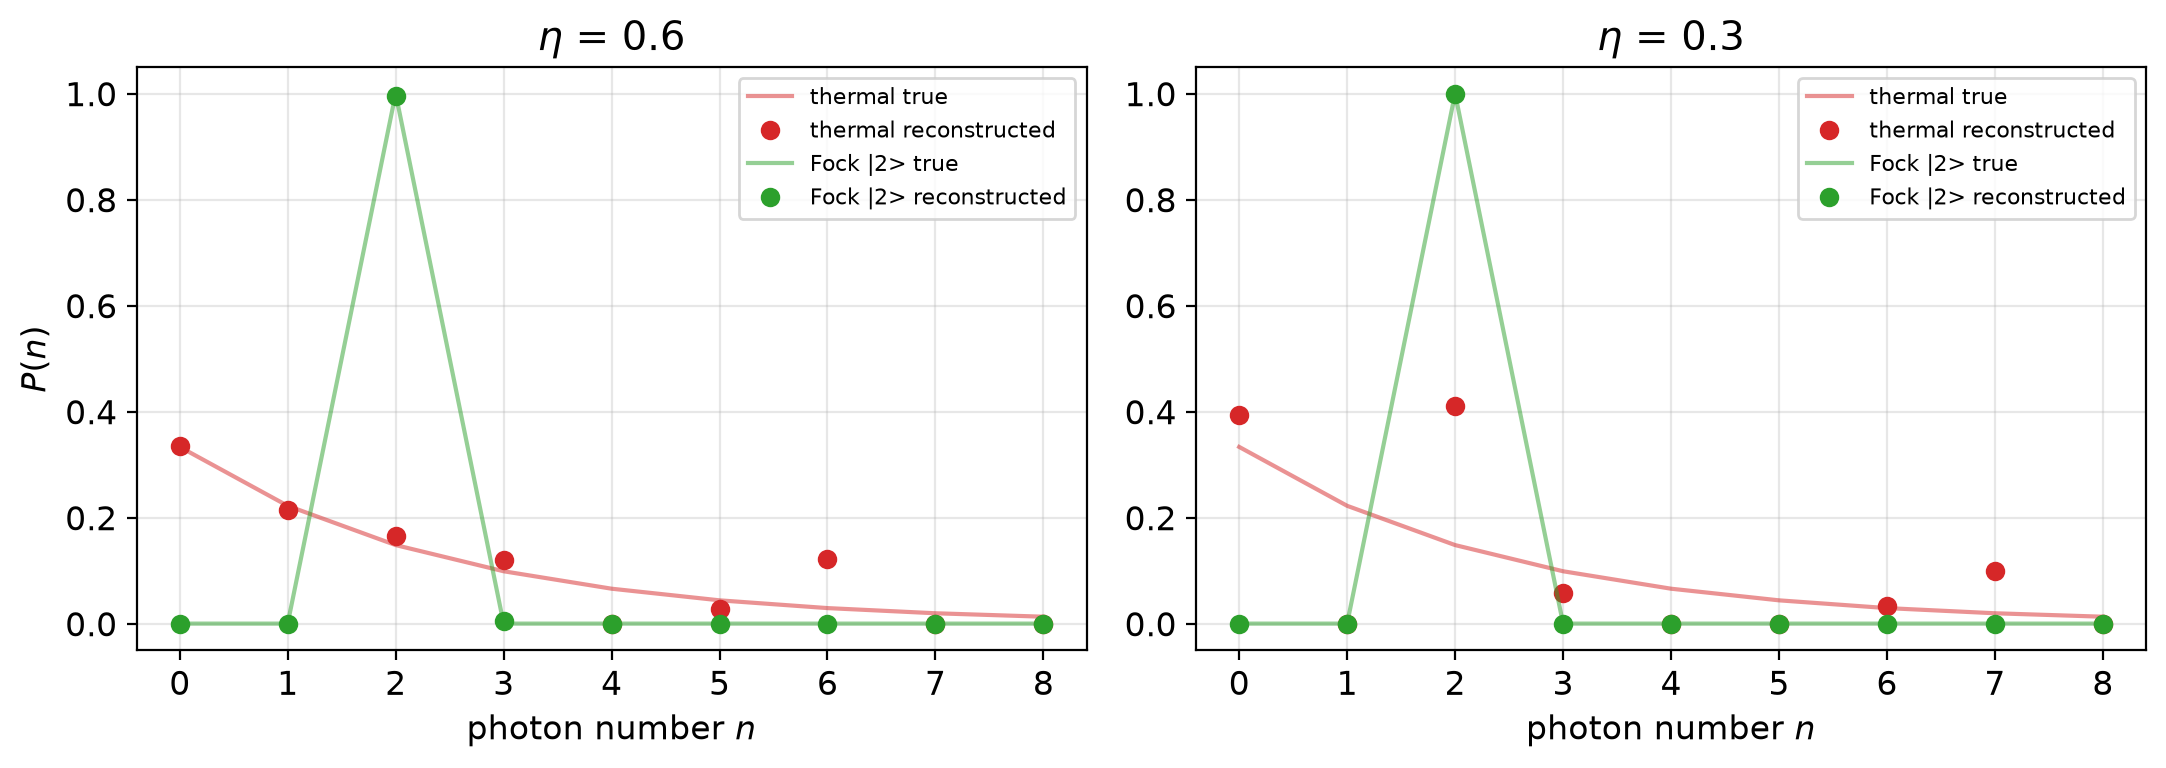

In [11]:
# Solution - Stretch exercise (P(n) reconstruction from clicks)
from scipy.optimize import nnls
from scipy.special import comb as scomb, factorial

rng = np.random.default_rng(4)
n_pulses, M, n_max = 20_000, 8, 25
nbar = 2.0
n_ax = np.arange(n_max)
sources_pn = {
    "thermal": nbar**n_ax / (1 + nbar)**(n_ax + 1),
    "Fock |2>": (n_ax == 2).astype(float),
}

def click_matrix(M: int, eta: float, n_max: int) -> np.ndarray:
    """A[k, n] = P(k clicks | n photons) for an M-bin multiplexed detector."""
    A = np.zeros((M + 1, n_max))
    for n in range(n_max):
        for m in range(n + 1):
            p_loss = scomb(n, m) * eta**m * (1 - eta)**(n - m)
            for k in range(min(m, M) + 1):
                occ = scomb(M, k) * sum(
                    (-1)**i * scomb(k, i) * ((k - i) / M)**m
                    for i in range(k + 1))
                A[k, n] += p_loss * occ
    return A

def simulate_clicks(P: np.ndarray, eta: float) -> np.ndarray:
    """Monte-Carlo click histogram C(k) for n_pulses pulses."""
    n_photons = rng.choice(n_ax, size=n_pulses, p=P / P.sum())
    C = np.zeros(M + 1)
    for n in n_photons:
        m = rng.binomial(n, eta)                      # loss
        k = len(set(rng.integers(0, M, m)))           # occupied bins
        C[k] += 1
    return C / n_pulses

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, eta in zip(axes, [0.6, 0.3]):
    A = click_matrix(M, eta, n_max)
    for label, P_true in sources_pn.items():
        C = simulate_clicks(P_true, eta)
        P_rec, _ = nnls(A, C)                         # non-negative inversion
        P_rec = P_rec / P_rec.sum()
        color = "tab:red" if "thermal" in label else "tab:green"
        ax.plot(n_ax[:9], P_true[:9], "-", color=color, alpha=0.5,
                label=f"{label} true")
        ax.plot(n_ax[:9], P_rec[:9], "o", color=color,
                label=f"{label} reconstructed")
    ax.set_title(f"$\\eta$ = {eta}")
    ax.set_xlabel("photon number $n$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$P(n)$")
plt.tight_layout(); plt.show()
# eta = 0.6: faithful reconstruction from binary detectors - this is how
# P(n) is measured in practice (time-multiplexed detectors, SNSPD arrays).
# eta = 0.3: the inversion amplifies statistical noise into spurious
# structure - loss makes A ill-conditioned. Photon-number tomography is
# an efficiency game, like everything else this week.